## Real Data Analysis: LPMC Data
Here I implement DeepHalo model with the LPMC real dataset. The data preprocessing and hyper-parameter setting are the same as in the appendix paper of Zhang(25).

In [ ]:
from DeepHalo import DeepHalo
import numpy as np
import pandas as pd
from choice_learn.data import ChoiceDataset
from choice_learn.data.storage import FeaturesStorage
import tensorflow as tf
from choice_learn.models.base_model import ChoiceModel
from tensorflow.keras.layers import Dense, LayerNormalization, BatchNormalization, ReLU, Dropout

In [2]:
#Read the data and do some pre-processing
LPMC = pd.read_csv('LPMC.csv')
cols = ['travel_mode', 'age', 'female', 'driving_license', 'car_ownership','distance','dur_walking','dur_cycling','dur_pt_total','dur_driving','cost_transit', 'cost_driving_total','pt_n_interchanges','driving_traffic_percent']
LPMC1 = LPMC[cols]

In [3]:
LPMC1 = LPMC1.rename(columns={
    "dur_pt_total": "dur_pt",
    "cost_transit": "cost_pt",
    "cost_driving_total": "cost_driving",
    "pt_n_interchanges": "interchanges_pt",
    "driving_traffic_percent": "congestion_driving"
})
LPMC1["travel_mode"] = LPMC1["travel_mode"].replace({
    "drive": "driving",
    "transit": "pt",
    "cycle": "cycling",
    "walk": "walking",
})

Since the method I implemented  is based on the choice_learn package, the input dataset is required to be transofmed into ChoiceDataset format using ChoiceDataset.from_single_wide_df() function. 

In [4]:
dataset1 = ChoiceDataset.from_single_wide_df(
    df=LPMC1,
    items_id=["walking", "cycling", "pt", "driving"],
    shared_features_columns=['age', 'female', 'driving_license', 'car_ownership','distance'],
    items_features_prefixes=["dur","cost",'interchanges','congestion'],
    choices_column="travel_mode"
)

We split the dataset into training and testing data set. We set 80% training and 20% testing.

In [19]:
import random
ind = list(range(81087))
random.shuffle(ind)
split_index = int(len(ind) * 0.8)
dataset1_training = dataset1[:split_index]
dataset1_testing = dataset1[split_index:]

Now we call the defined network DeepHalo() to fit the LPMC data:

In [39]:
model = DeepHalo(embedding_dim=32, L = 4, H = 8, optimizer="Adam", epochs=500)
history = model.fit(dataset1_training,val_dataset=dataset1_testing)

Epoch 499 Train Loss 0.7941: 100%|██████████| 500/500 [22:50<00:00,  2.74s/it]


Here we print the testing negative log-likelihood (NLL) value:

In [42]:
model.evaluate(dataset1)

<tf.Tensor: shape=(), dtype=float32, numpy=0.7917674779891968>

The training NLL loss is also plotted against 500 epochs.

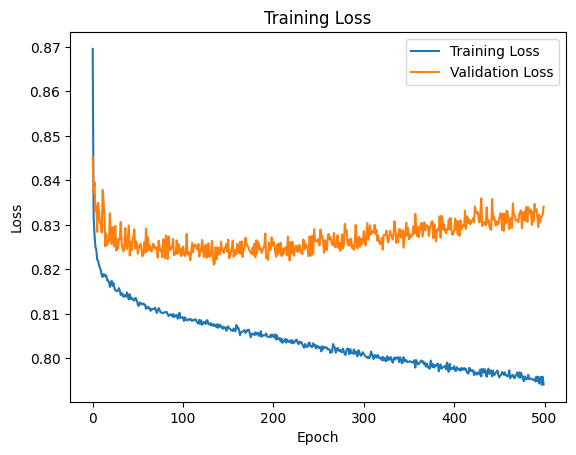

In [43]:
import matplotlib.pyplot as plt

# Assume 'history' is the object returned by model.fit()
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history["test_loss"], label='Validation Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()